In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

<div dir = "rtl">

### سوال اول : طبقه بندی ستارگان

</div>

<div dir = "rtl">

**1.1) داده ها را بخوانید و با دستور *()info.* بررسی کنید. کلاس ها را به صورت زیر به اعداد انکود کنید :**
</div>

*Galaxy : 0*

*Star : 1*

*Quasar : 2*


In [2]:
star = pd.read_csv('star.csv')
star.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7), str(1)
mem

In [3]:
Mapping = {'GALAXY': 0, 'STAR': 1,'QSO': 2}
star['class'] =star['class'].map(Mapping)
print(star['class'].value_counts())
star.info()

class
0    59445
1    21594
2    18961
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  int64  
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     1

<div dir = "rtl">
در این بخش کلاس ها را به اعداد 0 تا 2 انکود کردیم.

مشاهده می کنیم در ستون 13 که مربوط به کلِاس است DType از str به int64 تغییر کرده است که یعنی ما توانستیم داده ها را مپ کنیم.

</div>

<div dir = "rtl">

**1.2) ماتریس همبستگی ویژگی های موجود در فایل را رسم کنید. کدام ویژگی ها همبستگی بسیار کمی با class دارند؟ این ویژگی ها را حذف کنید.**
</div>

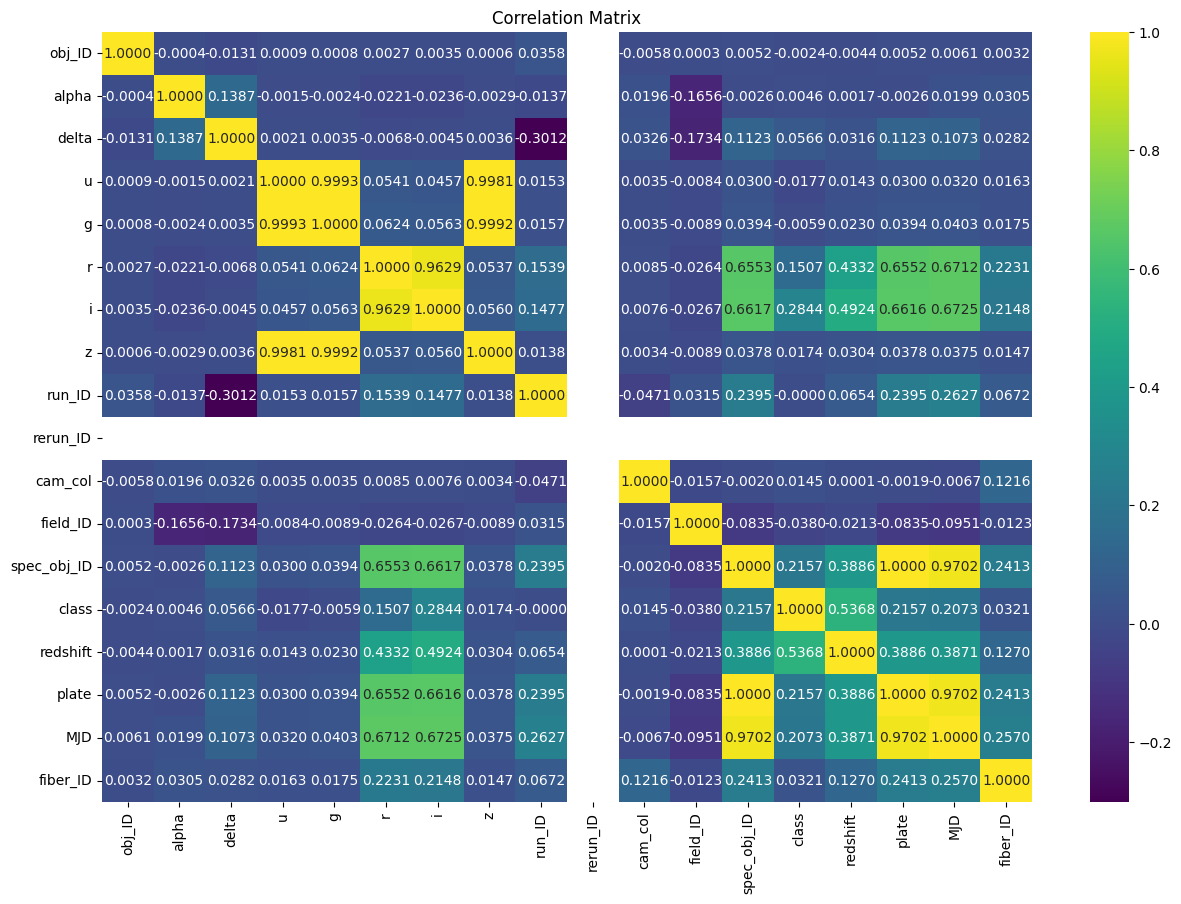

In [4]:

numeric_star = star.select_dtypes(include=np.number)
Correlation_matrix = numeric_star.corr()
plt.figure(figsize=(15,10))
sns.heatmap(Correlation_matrix,cmap='viridis',annot = True,fmt =".4f",)
plt.title('Correlation Matrix')
plt.show()
Correlation_c = Correlation_matrix['class']

Features with very low correlation:
['obj_ID', 'alpha', 'u', 'g', 'z', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'fiber_ID']


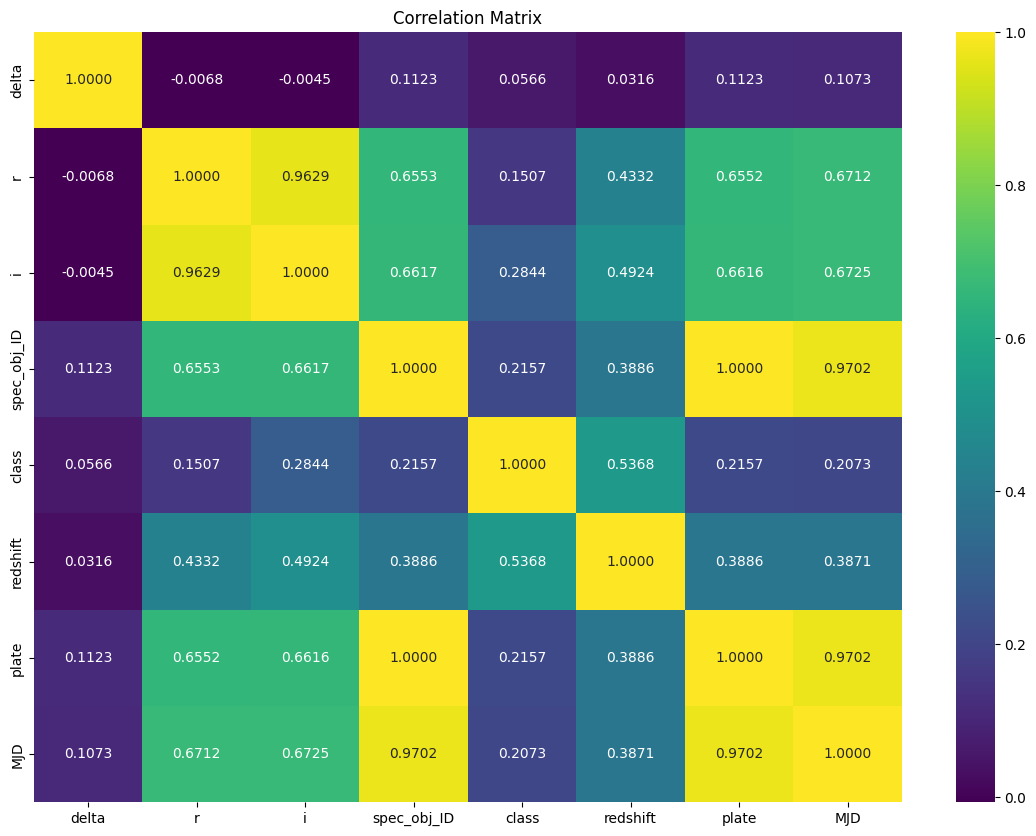

In [5]:
threshold = 0.05
LowCorrelation_f = Correlation_c[(abs(Correlation_c) < threshold) | (Correlation_c.isna())].index.tolist()
if 'class' in LowCorrelation_f:
    LowCorrelation_f.remove('class')
star_reduced = star.drop(columns=LowCorrelation_f)
print("Features with very low correlation:")
print(LowCorrelation_f)

numeric_star = star_reduced.select_dtypes(include=np.number)
Correlation_matrix = numeric_star.corr()
plt.figure(figsize=(14,10))
sns.heatmap( Correlation_matrix,cmap='viridis', annot = True,fmt =".4f",)
plt.title('Correlation Matrix')
plt.show()

<div dir = "rtl">
ابتدا ماتریس همبستگی ویژگی‌ ها را رسم کردم. سپس میزان همبستگی هر ویژگی با  class محاسبه کردم. ویژگی‌ هایی که قدر مطلق ضریب همبستگی آن‌ ها کمتر از 0.05 بود به عنوان ویژگی‌ های کم‌اثر در نظر گرفتیم و از مجموعه داده حذف کردیم تا پیچیدگی مدل کاهش یابد و از ورود ویژگی‌ های غیرمفید جلوگیری شود.
</div>

<div dir = "rtl">

**1.3)تعادل داده ها در کلاس های مختلف را بررسی کنید. آیا تعداد داده ها در کلاس های مختلف متعادل است؟ در صورتی که این طور نیست، با استفاده از تکنیک های under sampling، تعداد دیتا در کلاس های مختلف را یکی کنید.**
</div>

class
0    59445
1    21594
2    18961
Name: count, dtype: int64


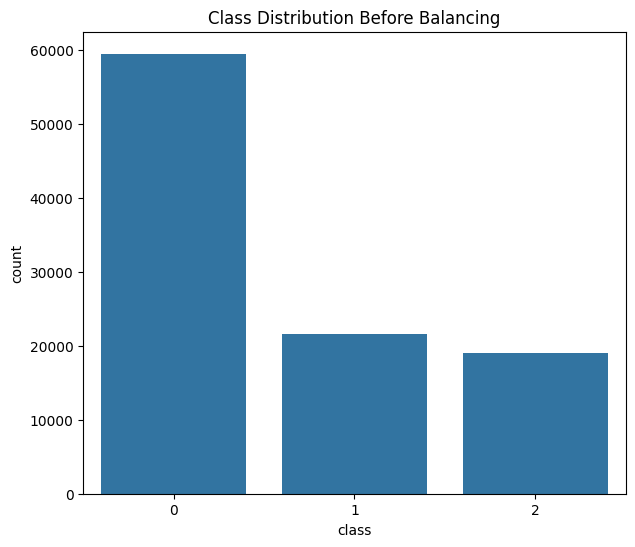

In [6]:
print(star_reduced['class'].value_counts())
plt.figure(figsize=(7,6))
sns.countplot(x='class', data=star_reduced)
plt.title('Class Distribution Before Balancing')
plt.show()

Before balancing:
class
0    59445
1    21594
2    18961
Name: count, dtype: int64

After balancing:
class
0    18961
1    18961
2    18961
Name: count, dtype: int64


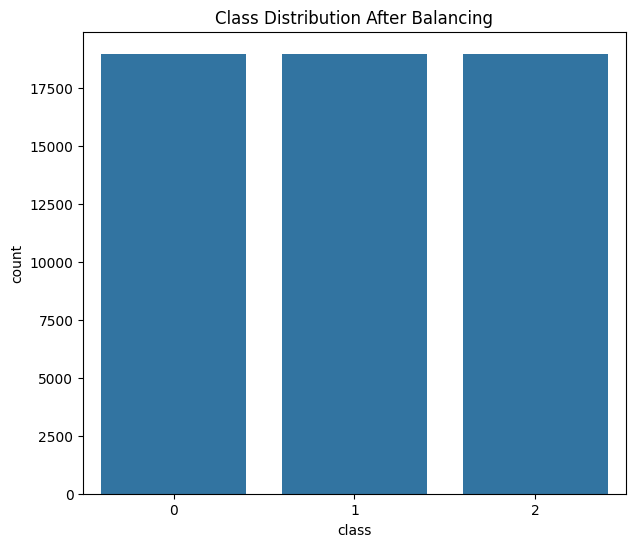

In [7]:
X = star_reduced.drop('class', axis=1)
y = star_reduced['class']
rus =RandomUnderSampler(random_state=42)
X_balanced, Y_balanced = rus.fit_resample(X, y)
print("Before balancing:")
print(y.value_counts())
print("\nAfter balancing:")
print(Y_balanced.value_counts())

balanced_star = X_balanced.copy()
balanced_star['class'] = Y_balanced
plt.figure(figsize=(7,6))
sns.countplot(x='class',data=balanced_star)
plt.title('Class Distribution After Balancing')
plt.show()

<div dir = "rtl">
ابتدا تعداد نمونه‌ های موجود در هر کلاس را بررسی می کنیم و می بینیم که توزیع داده‌ها بین کلاس‌ های Galaxy، Star و Quasar متعادل نیست. بنابراین با استفاده از روش Random Under Sampling تعداد نمونه های کلاس‌ ها برابر شد تا از ایجاد بایاس در فرآیند آموزش مدل جلوگیری شود. پس از نمونه‌ برداری مجدد تعداد نمونه های هر سه کلاس یکسان شد.
</div>

<div dir = "rtl">

**1.4) ویژگی ها را استاندارد کنید و سپس داده ها را 20 درصد برای تست و 80 درصد برای آموزش جدا کنید.**
</div>

In [8]:
X_Train,X_Test, Y_Train,Y_Test = train_test_split(X_balanced,Y_balanced,test_size=0.2,random_state= 61,stratify=Y_balanced)
scaler= StandardScaler()
X_Train_scaled= scaler.fit_transform(X_Train)
X_Test_scaled =scaler.transform(X_Test)
print("X_Train & Y_Train shape:",X_Train_scaled.shape[0])
print("X_Test & Y_Test shape :", X_Test_scaled.shape[0])

X_Train & Y_Train shape: 45506
X_Test & Y_Test shape : 11377


<div dir = "rtl">
پس از متعادل‌ سازی داده‌ ها مجموعه داده به نسبت 80 درصد برای آموزش و 20 درصد برای آزمون تقسیم کردیم. برای جلوگیری از تاثیر مقیاس متفاوت ویژگی‌ها بر عملکرد مدل، از روش StandardScaler استفاده کردیم. پارامترهای استانداردسازی تنها روی داده های آموزشی محاسبه شده و سپس همان تبدیل روی داده های آزمون اعمال شد تا از Data Leakage جلوگیری شود.
</div>

<div dir = "rtl">

**1.5)می خواهیم با استفاده از SVM داده ها را طبقه بندی کنیم، با استفاده از کرنل خطی و مقادیر 0.1،1،10 برای پارامتر C مدل را تعریف کنید و به ازای هر کدام از مقادیر C، مدل را ارزیابی کنید.**
</div>

In [ ]:
C_values = [0.1, 1, 10]
results = {}
for C in C_values:
    print("="*60)
    print(f"SVM Linear Kernel (C={C})")
    SVM_model = SVC(kernel='linear', C=C,probability=True,random_state=61)
    SVM_model.fit(X_Train_scaled, Y_Train)
    Y1 = SVM_model.predict(X_Test_scaled)

    Accuracy = accuracy_score(Y_Test, Y1)
    Recall = recall_score(Y_Test,Y1,average='macro')
    F1 = f1_score(Y_Test,Y1, average='macro' )
    results[C] = [Accuracy, Recall,F1]
    print(f"Accuracy = {Accuracy:.4f}")
    print(f"Recall   = {Recall:.4f}")
    print(f"F1-Score = {F1:.4f}")
    print()

SVM Linear Kernel (C=0.1)
Accuracy = 0.9446
Recall   = 0.9446
F1-Score = 0.9443

SVM Linear Kernel (C=1)
Accuracy = 0.9565
Recall   = 0.9565
F1-Score = 0.9564

SVM Linear Kernel (C=10)


<Figure size 700x600 with 0 Axes>

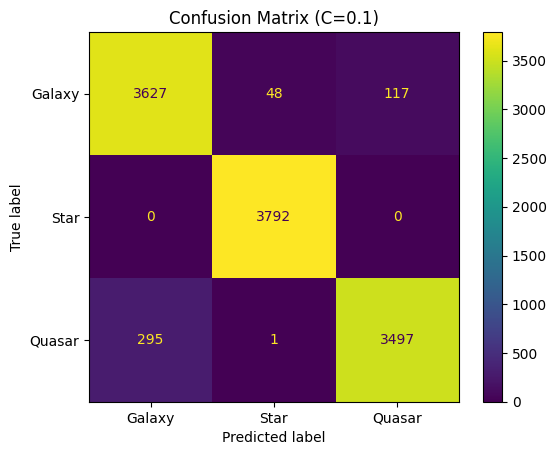

<Figure size 700x600 with 0 Axes>

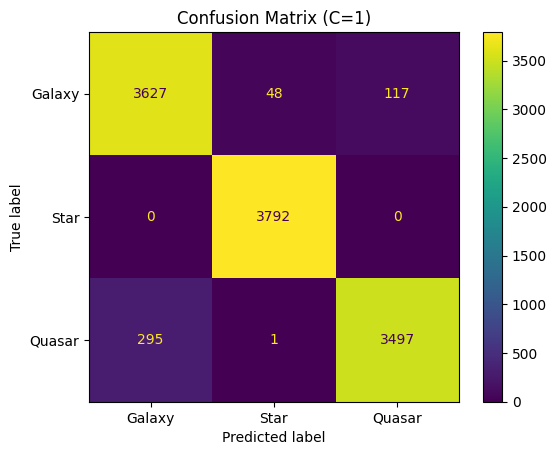

<Figure size 700x600 with 0 Axes>

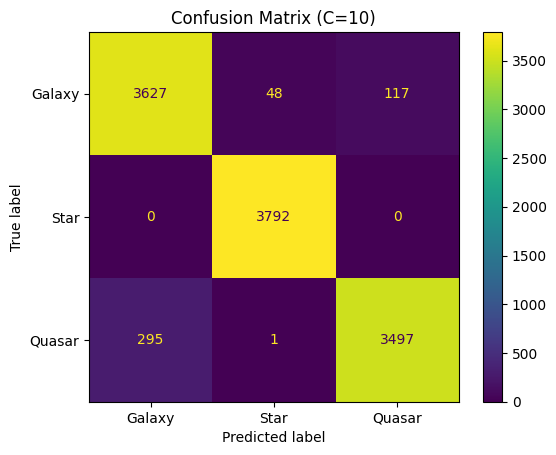

In [ ]:
for C in C_values:
    Confusion_Matrix = confusion_matrix(Y_Test,Y1)
    plt.figure(figsize=(7,6))
    disp = ConfusionMatrixDisplay(confusion_matrix=Confusion_Matrix,display_labels=["Galaxy","Star","Quasar"] )
    disp.plot(cmap='viridis')
    plt.title(f"Confusion Matrix (C={C})")
    plt.show()

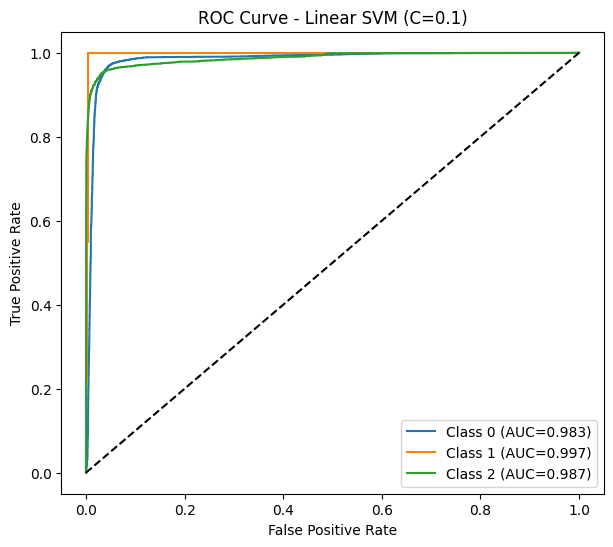

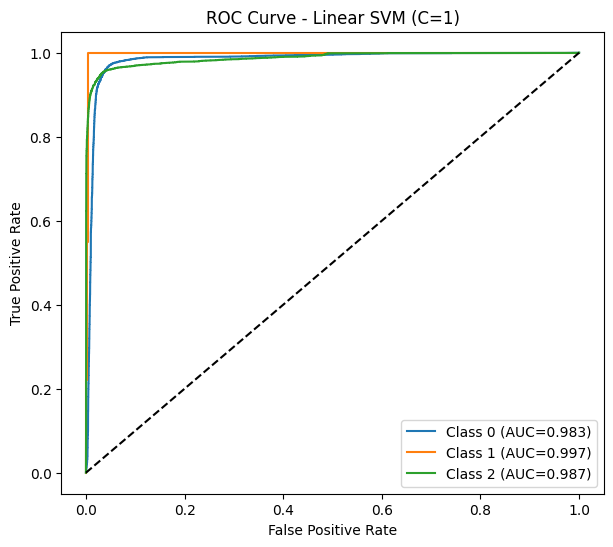

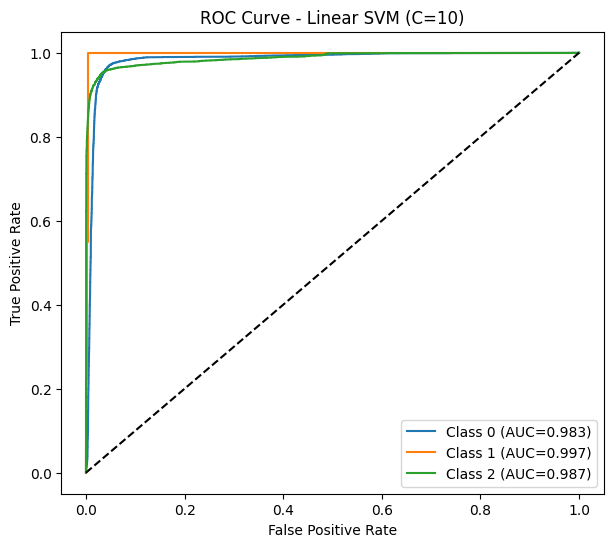

In [ ]:
classes = [0,1,2]
Y2 = label_binarize(Y_Test,classes=classes)
for C in C_values:
    y_score = SVM_model.predict_proba(X_Test_scaled)
    plt.figure(figsize=(7,6))
    for i in range(3):
        FP, TP, _ = roc_curve(Y2[:, i],y_score[:, i])
        ROC = auc(FP, TP)
        plt.plot( FP,TP,label=f"Class {i} (AUC={ROC:.3f})")
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - Linear SVM (C={C})")
    plt.legend()
    plt.show()

<div dir = "rtl">
در این بخش ما با استفاده از SVM و مقدار C های متفاوت عملکرد رو بررسی کردیم.
همان‌ طور که مشاهده می‌ شود با افزایش مقدار پارامتر C عملکرد مدل بهبود یافته است. مقدار C میزان جریمه خطاهای طبقه‌ بندی را کنترل می‌ کند پس هرچه این مقدار بزرگ‌ تر باشد مدل تلاش بیشتری برای کاهش خطاهای آموزشی انجام می‌ دهد. در این مجموعه داده افزایش C از 0.1 به 10 باعث افزایش Accuracy شده است.

همچنین مقادیر Recall و F1-Score تقریبا برابر با Accuracy هستند که نشان می‌ دهد مدل در تشخیص هر سه کلاس Galaxy، Star و Quasar عملکرد متعادلی داشته است. این موضوع با توجه به متعادل‌ سازی داده‌ ها در بخش های قبل قابل انتظار است.

بر اساس نتایج به‌ دست‌ آمده بهترین عملکرد مربوط به مدل SVM با کرنل خطی و مقدار C=10 است که بیشترین Accuracy، Recall و F1-Score را دارد. همچنین بررسی ماتریس‌ و منحنی‌ های ROC نشان می‌ دهد که مدل توانایی بالایی در تفکیک کلاس‌ های مختلف داشته و نرخ خطای طبقه‌ بندی نسبتا پایین است.
</div>



<div dir = "rtl">

**1.6)حال با آموزش یک مدل Logistic Regression داده ها را طبقه‌ بندی کرده و مدل را ارزیابی کنید.**
</div>

In [ ]:
Logistic = LogisticRegression(max_iter=5000,random_state=61)
Logistic.fit(X_Train_scaled, Y_Train)
Y1 =Logistic.predict(X_Test_scaled)
Accuracy = accuracy_score(Y_Test, Y1)
Recall = recall_score(Y_Test,Y1,average='macro')
F1 = f1_score( Y_Test, Y1, average='macro')
print(f"Accuracy = {Accuracy:.4f}")
print(f"Recall   = {Recall:.4f}")
print(f"F1-Score = {F1:.4f}")

Accuracy = 0.9489
Recall   = 0.9489
F1-Score = 0.9487


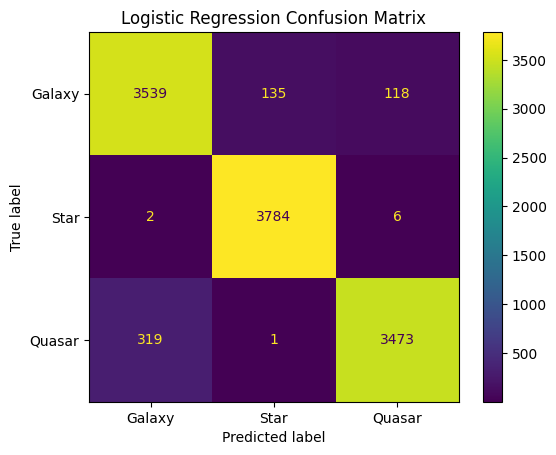

In [ ]:
Confusion_Matrix = confusion_matrix(Y_Test, Y1)
disp = ConfusionMatrixDisplay(confusion_matrix=Confusion_Matrix,display_labels=["Galaxy","Star","Quasar"])
disp.plot(cmap='viridis')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

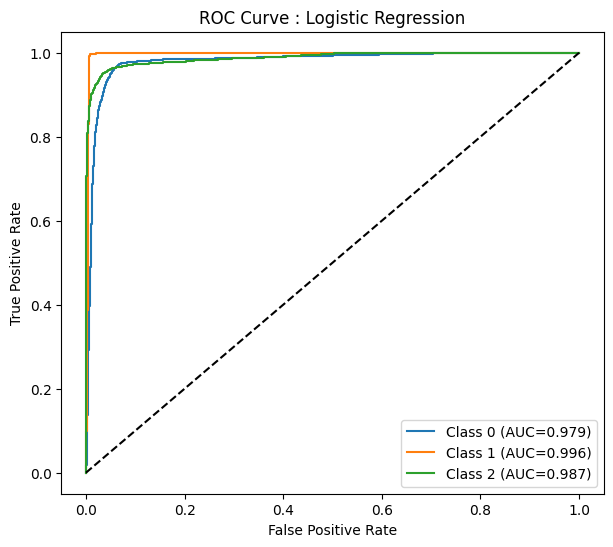

In [ ]:
classes = [0,1,2]
Y2 = label_binarize(Y_Test,classes=classes)
y_score = Logistic.predict_proba(X_Test_scaled)
plt.figure(figsize=(7,6))
for i in range(3):
    FP, TP, _ =roc_curve(Y2[:, i],y_score[:, i])
    ROC = auc(FP, TP)
    plt.plot( FP,TP,label=f"Class {i} (AUC={ROC:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve : Logistic Regression")
plt.legend()
plt.show()

<div dir = "rtl">
در این بخش از الگوریتم Logistic Regression برای طبقه‌ بندی استفاده کردیم. پس از آموزش مدل روی داده های آموزشی عملکرد آن روی داده های تست را ارزیابی کردیم. معیارهای Accuracy، Recall و F1-Score را محاسبه کردیم و همچنین ماتریس و منحنی ROC برای بررسی کیفیت طبقه‌ بندی رسم کردیم. نتایج نشان می دهد که مدل Logistic Regression می تواند با دقت مناسبی سه کلاس Galaxy، Star و Quasar را از یکدیگر تفکیک کند.


از نظر تئوری Logistic Regression یک مدل خطی مبتنی بر احتمال است که با استفاده از تابع Softmax احتمال تعلق هر نمونه به کلاس‌ های مختلف را محاسبه می‌ کند. این مدل علاوه بر سادگی سرعت آموزش بالا و قابلیت تفسیر مناسبی دارد و ضرایب آن مستقیما اهمیت ویژگی‌ ها را نشان می‌ دهند.

در مقابل SVM به جای مدل‌ سازی احتمال تلاش می‌ کند که حاشیه بین کلاس‌ ها را بیشینه کند. بیشینه‌ سازی این حاشیه معمولا باعث افزایش قدرت تعمیم مدل روی داده های جدید می‌ شود. به همین دلیل در بسیاری از مسائل طبقه‌ بندی SVM عملکرد بهتری از Logistic Regression ارائه می‌ دهد.

با توجه به نتایج این آزمایش اگر هدف دستیابی به بیشترین دقت طبقه‌ بندی باشد، مدل SVM با مقدار C=10 انتخاب مناسب‌ تری است. اما اگر هدف تحلیل اثر ویژگی‌ ها و تفسیر مدل باشد، Logistic Regression گزینه مناسب‌ تری خواهد بود.
</div>

<div dir = "rtl">

**1.7)در مدل Logistic Regression ضرایب به دست آمده در مدل و رابطه هر ویژگی با خروجی را بررسی کنید. کدام ویژگی ها مهم ترند و چرا؟**
</div>

In [ ]:
feature_names = X.columns
star_c = pd.DataFrame(Logistic.coef_.T,index=feature_names,columns=['Galaxy','Star', 'Quasar'])
star_c

,Galaxy,Star,Quasar
delta,-0.053309,-0.090312,0.143621
r,2.200269,1.596931,-3.797201
i,-2.258081,-1.120825,3.378906
spec_obj_ID,0.313351,-0.450804,0.137453
redshift,15.028210,-35.108683,20.080472
plate,0.290048,-0.448709,0.158661
MJD,-0.618466,1.067847,-0.449381


In [ ]:
feature_importance = pd.DataFrame({'Feature': feature_names,'Importance': np.mean(np.abs(Logistic.coef_), axis=0)})
feature_importance = feature_importance.sort_values(  by='Importance',ascending=False)
feature_importance

,Feature,Importance
4,redshift,23.405788
1,r,2.531467
2,i,2.252604
6,MJD,0.711898
3,spec_obj_ID,0.300536
5,plate,0.299139
0,delta,0.095747


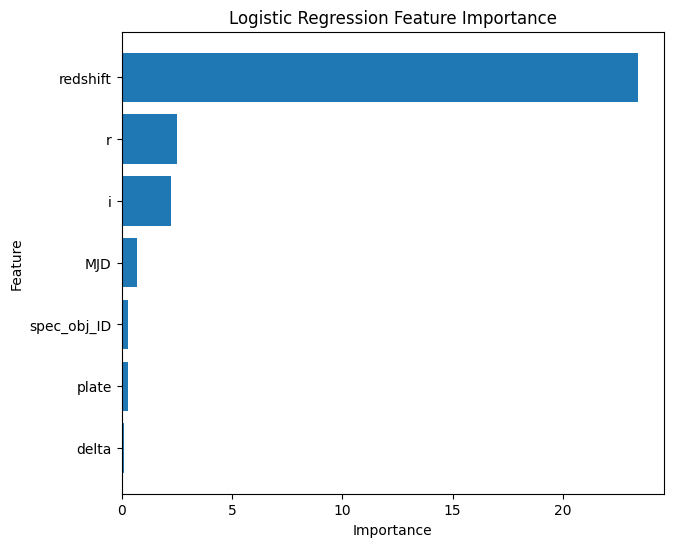

In [ ]:
plt.figure(figsize=(7,6))
plt.barh(feature_importance['Feature'],feature_importance['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Logistic Regression Feature Importance')
plt.gca().invert_yaxis()
plt.show()

<div dir = "rtl">
برای تحلیل مدل Logistic Regression، ضرایب یاد گرفته‌ شده توسط مدل مورد بررسی قرار می گیرند. در این مدل هر ضریب نشان‌ دهنده میزان تاثیر یک ویژگی بر تصمیم‌گیری مدل است. هرچه قدر مطلق ضریب بزرگ‌ تر باشد آن ویژگی نقش بیشتری در تعیین کلاس خروجی خواهد داشت. همچنین علامت ضریب مشخص می‌ کند که افزایش مقدار ویژگی احتمال تعلق نمونه به یک کلاس خاص را افزایش یا کاهش می‌ دهد.

نتایج نشان داد که ویژگی redshift مهم‌ ترین ویژگی مدل است و فاصله قابل توجهی با سایر ویژگی‌ ها دارد. این موضوع نشان می‌ دهد که تغییرات این ویژگی بیشترین تاثیر را بر مرزهای تصمیم مدل داشته و مدل برای تفکیک کلاس‌ ها وابستگی زیادی به آن پیدا کرده است. ضرایب بزرگ این ویژگی برای هر سه کلاس نیز نشان می‌ دهد که مدل از آن به عنوان مهم‌ ترین عامل تمایز بین کلاس‌ ها استفاده می‌ کند.

پس از آن ویژگی‌ های r و i قرار دارند. مقدار نسبتا بزرگ ضرایب این دو ویژگی نشان می‌ دهد که آن‌ها نیز سهم قابل توجهی در فرآیند طبقه‌ بندی دارند و اطلاعات مفیدی برای تفکیک کلاس‌ ها در اختیار مدل قرار می‌ دهند.

کم‌اهمیت‌ ترین ویژگی در مدل delta است. کوچک بودن ضرایب این ویژگی بیان می‌ کند که تغییرات آن تاثیر اندکی بر خروجی مدل داشته و اطلاعات تفکیک‌ کننده چندانی برای تشخیص کلاس‌ ها فراهم نمی‌ کند.

به طور کلی توزیع ضرایب نشان می‌ دهد که مدل تصمیم‌ گیری خود را بر پایه تعداد محدودی از ویژگی‌ های بسیار تاثیرگذار انجام داده است. این موضوع نشان‌ دهنده آن است که اطلاعات مربوط به کلاس‌ ها در این مجموعه داده به طور یکنواخت بین همه ویژگی‌ ها توزیع نشده و بخش عمده قدرت تفکیک داده‌ها در چند ویژگی متمرکز شده است.

</div>

<div dir = "rtl">

### سوال دوم : تشخیص زودهنگام حمله قلبی

</div>

<div dir = "rtl">

**2.1)با استفاده از دستور *()info.* بررسی کنید آیا ستونی از داده ها، دارای خانه های خالی هستند یا خیر؟ در صورتی که خانه خالی ای وجود دارد سطرهای مناسب با آن ها را حذف کنید.**
</div>

In [ ]:
Heart_Attack = pd.read_csv('heart_attack_risk.csv')
Heart_Attack.info()

<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              8763 non-null   int64  
 1   Sex                              8763 non-null   str    
 2   Cholesterol                      8763 non-null   int64  
 3   Blood Pressure                   8763 non-null   str    
 4   Heart Rate                       8763 non-null   int64  
 5   Diabetes                         8763 non-null   int64  
 6   Family History                   8763 non-null   int64  
 7   Smoking                          8763 non-null   int64  
 8   Obesity                          8763 non-null   int64  
 9   Alcohol Consumption              8763 non-null   int64  
 10  Exercise Hours Per Week          8763 non-null   float64
 11  Diet                             8763 non-null   str    
 12  Previous Heart Problems        

In [ ]:
Heart_Attack = Heart_Attack.dropna()
Heart_Attack.info()

<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              8763 non-null   int64  
 1   Sex                              8763 non-null   str    
 2   Cholesterol                      8763 non-null   int64  
 3   Blood Pressure                   8763 non-null   str    
 4   Heart Rate                       8763 non-null   int64  
 5   Diabetes                         8763 non-null   int64  
 6   Family History                   8763 non-null   int64  
 7   Smoking                          8763 non-null   int64  
 8   Obesity                          8763 non-null   int64  
 9   Alcohol Consumption              8763 non-null   int64  
 10  Exercise Hours Per Week          8763 non-null   float64
 11  Diet                             8763 non-null   str    
 12  Previous Heart Problems        

<div dir = "rtl">
ابتدا مجموعه‌ داده heart_attack_risk.csv با استفاده از تابع info() مورد بررسی قرار می گیرد تا وجود داده‌ های گمشده مشخص شود. نتایج نشان می دهد همه ستون‌ ها غیر تهی است. پس خیر هیچ مقدار تهی ای در داده ها وجود ندارد و نیازی به حذف سطرها نیست.
</div>

<div dir = "rtl">

**2.2)ویژگی هایی که به صورت یک عدد نیستند را به طور مناسبی به اعدای متناظر کنید.**
</div>

In [ ]:
Heart_Attack[['Systolic', 'Diastolic']] = Heart_Attack['Blood Pressure'].str.split('/', expand=True)
Heart_Attack['Systolic'] = Heart_Attack['Systolic'].astype(int)
Heart_Attack['Diastolic'] = Heart_Attack['Diastolic'].astype(int)
Heart_Attack = Heart_Attack.drop(columns=['Blood Pressure'])
le = LabelEncoder()
Heart_Attack['Sex'] = le.fit_transform(Heart_Attack['Sex'])
Heart_Attack['Diet'] = le.fit_transform(Heart_Attack['Diet'])
Heart_Attack['Hemisphere'] = le.fit_transform(Heart_Attack['Hemisphere'])
continent = pd.get_dummies(Heart_Attack['Continent'], prefix='Continent', dtype=int)
Heart_Attack = pd.concat([Heart_Attack, continent], axis=1)
Heart_Attack = Heart_Attack.drop(columns=['Continent'])
Heart_Attack.info()

<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              8763 non-null   int64  
 1   Sex                              8763 non-null   int64  
 2   Cholesterol                      8763 non-null   int64  
 3   Heart Rate                       8763 non-null   int64  
 4   Diabetes                         8763 non-null   int64  
 5   Family History                   8763 non-null   int64  
 6   Smoking                          8763 non-null   int64  
 7   Obesity                          8763 non-null   int64  
 8   Alcohol Consumption              8763 non-null   int64  
 9   Exercise Hours Per Week          8763 non-null   float64
 10  Diet                             8763 non-null   int64  
 11  Previous Heart Problems          8763 non-null   int64  
 12  Medication Use                 

<div dir = "rtl">
در این بخش ویژگی‌ های غیرعددی به مقادیر عددی تبدیل شدند. ابتدا ستون Blood Pressure که شامل مقادیر فشار خون سیستولیک و دیاستولیک به‌ صورت یک رشته بود، به دو ستون مجزای Systolic و Diastolic تفکیک شد و ستون اولیه حذف شد. سپس ویژگی‌ های Sex، Diet و Hemisphere با استفاده از روش Label Encoding به مقادیر عددی تبدیل شدند. از آنجا که ستون Continent شامل شش دسته مستقل و بدون ترتیب است با استفاده از روش One-Hot Encoding به شش ستون دودویی مجزا تبدیل شد تا از ایجاد رابطه ترتیبی بین قاره ها جلوگیری شود.
</div>

<div dir = "rtl">

**2.3)داده ها را به صورت رندوم 80 درصد برای آموزش و 20 درصد برای تست جداسازی کرده و داده ها را نرمالایز کنید.**
</div>

In [ ]:
X = Heart_Attack.drop(columns=['Heart Attack Risk'])
y = Heart_Attack['Heart Attack Risk']
X_Train, X_Test, Y_Train, Y_Test = train_test_split(X, y,test_size= 0.2, random_state= 61)
scaler = MinMaxScaler()
X_Train = scaler.fit_transform(X_Train)
X_Test = scaler.transform(X_Test)
print("X_Train & Y_Train shape:", X_Train.shape[0])
print("X_Test & Y_Test shape :", X_Test.shape[0])

X_Train & Y_Train shape: 7010
X_Test & Y_Test shape : 1753


<div dir = "rtl">
در این بخش مجموعه داده به دو بخش آموزش و تست تقسیم می شود. 80 درصد داده ها برای آموزش مدل و 20 درصد برای تست عملکرد آن در نظر گرفته شد. 

پس از جداسازی داده ها ویژگی‌ های ورودی را نرمال‌ سازی کردیم. در این روش، مقادیر هر ویژگی به بازه [0,1] نگاشت می‌ شوند. پارامترهای نرمال‌ سازی تنها از داده های آموزشی استخراج می شوند و سپس همان پارامترها برای نرمال‌ سازی داده‌ های تست مورد استفاده قرار می گیرند تا از نشت اطلاعات از مجموعه تست به مجموعه آموزش جلوگیری شود.
</div>

<div dir = "rtl">

**2.4)این مجموعه داده ها را با کمک یک SVM با کرنل RBF طبقه بندی کرده و به ازای مقادیر مختلف پارامتری های C و gamma، صحت طبقه بندها را مقایسه کنید.**
</div>

In [ ]:
C_values = [0.1, 1, 10,100]
gamma_values = [0.001,0.01, 0.1, 1]
for C in C_values:
    for gamma in gamma_values:
        SVM= SVC(kernel='rbf', C=C, gamma=gamma)
        SVM.fit(X_Train, Y_Train)
        Y1= SVM.predict(X_Test)
        Accuracy =accuracy_score(Y_Test, Y1)
        print(f'C = {C}, gamma = {gamma}, Accuracy = {Accuracy:.4f}')

C = 0.1, gamma = 0.001, Accuracy = 0.6423
C = 0.1, gamma = 0.01, Accuracy = 0.6423
C = 0.1, gamma = 0.1, Accuracy = 0.6423
C = 0.1, gamma = 1, Accuracy = 0.6423
C = 1, gamma = 0.001, Accuracy = 0.6423
C = 1, gamma = 0.01, Accuracy = 0.6423
C = 1, gamma = 0.1, Accuracy = 0.6423
C = 1, gamma = 1, Accuracy = 0.6332
C = 10, gamma = 0.001, Accuracy = 0.6423
C = 10, gamma = 0.01, Accuracy = 0.6423
C = 10, gamma = 0.1, Accuracy = 0.6286
C = 10, gamma = 1, Accuracy = 0.6081
C = 100, gamma = 0.001, Accuracy = 0.6423
C = 100, gamma = 0.01, Accuracy = 0.6423
C = 100, gamma = 0.1, Accuracy = 0.5682
C = 100, gamma = 1, Accuracy = 0.6081


<div dir = "rtl">
در این بخش یک طبقه‌ بند SVM با کرنل RBF برای پیش‌ بینی ریسک حمله قلبی آموزش داده می شود. به منظور بررسی تأثیر پارامترهای مدل بر عملکرد طبقه‌بند مقادیر مختلفی برای پارامترهای C و gamma انتخاب شده و صحت طبقه‌ بندی برای هر ترکیب پارامتری محاسبه می شود.

نتایج نشان می دهند که برای اکثر ترکیب های پارامترها مقدار صحت ها برابر است. که بیشترین صحت به دست آمده نیز همین مقدار است که برای چندین ترکیب مختلف برقرار است.

همچنین مشخص می شود که با افزایش مقدار gamma به ویژه برای مقادیر بزرگ‌ تر C عملکرد مدل کاهش می‌ یابد. به عنوان مثال برای C=100 و γ=0.1 و برای C=10 و C=100 همراه با γ=1 دقت کاهش یافته است. این موضوع نشان می‌ دهد که انتخاب مقادیر بزرگ برای پارامتر gamma می‌ تواند منجر به Overfitting مدل و کاهش توانایی تعمیم آن بر روی داده های تست شود. این نتایج نشان می‌ دهد که مدل نسبت به تغییرات کوچک این پارامترها حساسیت زیادی نداشته است.
</div>

<div dir = "rtl">

**2.5)الگوریتم Perceptron را پیاده سازی کنید و با استفاده از آن داده ها را طبقه بندی کرده و مدل را ارزیابی کنید.**
</div>

In [ ]:
class Perceptron:
    def __init__(self, lr=0.01,epochs=100):
        self.lr = lr
        self.epochs = epochs
    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        self.b =0
        y = np.where(y == 0,-1,1)
        for _ in range(self.epochs):
            for i in range(len(X)):
                Y1 = np.sign(np.dot(X[i],self.w) + self.b)
                if Y1 != y[i]:
                    self.w += self.lr * y[i] *X[i]
                    self.b += self.lr *y[i]
    def predict(self, X):
        Y1 = np.sign(np.dot(X,self.w) + self.b)
        return np.where(Y1== -1, 0, 1)

Perceptron_Dasti = Perceptron(lr=0.01,epochs=100)
Perceptron_Dasti.fit(X_Train, Y_Train)
Y1 = Perceptron_Dasti.predict(X_Test)
Accuracy =accuracy_score(Y_Test, Y1)
print(f'Accuracy = {Accuracy:.4f}')

Accuracy = 0.6052


<div dir = "rtl">
در این بخش الگوریتم Perceptron را به صورت دستی پیاده سازی کردیم. ابتدا وزن‌ ها و بایاس مدل مقداردهی اولیه شدند و سپس در طی فرآیند آموزش با استفاده از قانون یادگیری پرسپترون وزن‌ ها و بایاس در صورت وقوع خطای طبقه‌ بندی به‌روزرسانی می شوند.

پس از اتمام آموزش عملکرد مدل بر روی مجموعه داده تست ارزیابی می شود و معیار Accuracy برای سنجش دقت طبقه‌ بندی محاسبه می شود. نتایج نشان می دهد که مدل پرسپترون توانست به صحت 60.52٪ بر روی داده های تست دست پیدا کند. این مقدار می گوید که مدل در پیش‌ بینی ریسک حمله قلبی عملکرد قابل قبولی داشته است اما در مقایسه با مدل SVM با کرنل RBF که دقتی برابر با 64.23٪ به دست آورد، عملکرد ضعیف‌ تری از خود نشان داده است.
</div>

<div dir = "rtl">

**2.6)قسمت قبل را این بار با توابع آماده Perceptron انجام داده و نتایج مدل را با بخش قبل مقایسه کنید.**
</div>

In [ ]:
from sklearn.linear_model import Perceptron
Perceptron_Amade = Perceptron(max_iter=100,eta0=0.01,random_state=61)
Perceptron_Amade.fit(X_Train, Y_Train)
Y1 = Perceptron_Amade.predict(X_Test)
Accuracy=accuracy_score(Y_Test, Y1)
print(f'Accuracy = {Accuracy:.4f}')

Accuracy = 0.5687


<div dir = "rtl">
در این بخش به جای پیاده سازی دستی الگوریتم پرسپترون از کلاس آماده Perceptron موجود برای طبقه بندی داده های مربوط به ریسک حمله قلبی استفاده می شود. مدل با استفاده از داده های آموزش، آموزش داده شده و سپس عملکرد آن بر روی مجموعه داده تست مورد ارزیابی قرار می گیرد. معیار Accuracy برای سنجش کیفیت طبقه‌ بندی محاسبه می شود.

نتایج نشان می دهد که مدل پرسپترون پیاده سازی‌ شده با استفاده از توابع آماده در مقایسه با پیاده سازی دستی الگوریتم پرسپترون صحت کمتری دارد. این اختلاف می‌ تواند ناشی از تفاوت در نحوه آموزش و یا ترتیب نمونه های آموزش باشد.

به طور کلی نتایج نشان می‌ دهند که در این مسئله پیاده‌ سازی دستی پرسپترون عملکرد بهتری نسبت به نسخه آماده دارد، هرچند هر دو مدل از نظر صحت عملکرد ضعیف‌ تری نسبت به طبقه‌ بند SVM با کرنل RBF دارند.
</div>

<div dir = "rtl">

**2.7)حال می خواهیم با استفاده از MLP داده ها را طبقه بندی کنیم. در رابطه با پارامترهای مختلف این مدل تحقیق کرده و با استفاده از GridSearchCV، شبکه عصبی خود را تعریف کنید و مدل را ارزیابی کنید.**
</div>

In [ ]:

MLP = MLPClassifier(max_iter=500, random_state=61)
Parameter = {'hidden_layer_sizes': [(50,), (100,), (50,50)],'activation': ['relu', 'tanh', 'logistic'],'alpha': [0.0001, 0.001]}
grid = GridSearchCV(  MLP,Parameter,cv=5,scoring='accuracy',n_jobs=-1)
grid.fit(X_Train, Y_Train)
best_model = grid.best_estimator_
Y1 = best_model.predict(X_Test)
Accuracy =accuracy_score(Y_Test,Y1)
print("Best Parameters:", grid.best_params_)
print(f"Accuracy = {Accuracy:.4f}")

Best Parameters: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (100,)}
Accuracy = 0.6423


<div dir = "rtl">
در این بخش از MLP برای طبقه بندی داده های مربوط به ریسک حمله قلبی استفاده می شود. برای انتخاب مناسب‌ ترین ساختار شبکه و پارامترهای مدل از روش GridSearchCV استفاده می شود. پارامترهای مورد بررسی شامل تعداد نورون‌ های لایه پنهان، تابع فعال‌ سازی و ضریب alpha هستند.

نتایج MLP نشان می دهد که بهترین عملکرد مربوط به شبکه ای با یک لایه پنهان شامل 100 نورون، تابع فعال‌ سازی tanh و ضریب alpha 0.0001 است. این شبکه توانست بر روی مجموعه داده آزمون به صحت خوبی دست پیدا کند.

با مقایسه نتایج مدل های مختلف مشاهده می‌ کنیم که شبکه عصبی MLP عملکردی بهتر از پرسپترون دستی و پرسپترون با توابع آماده دارد. همچنین صحت به‌دست آمده توسط MLP با بهترین نتیجه حاصل از SVM با کرنل RBF برابر بوده و هر دو مدل به صحت 64.23٪ رسیده اند. این موضوع نشان می‌ دهد که استفاده از مدل‌ های غیرخطی مانند MLP و SVM می‌ تواند نسبت به مدل خطی پرسپترون توانایی بیشتری در یادگیری الگوهای موجود در این مجموعه داده داشته باشد.
</div>

<div dir = "rtl">

**2.8)این بار یک مدل درخت تصمیم طراحی کنید. بهترین پارامترهای درخت را یافته و سپس با DecisionTreeClassifer و پارامترها، داده ها را طبقه بندی کرده و مدل را ارزیابی کنید.**
</div>

In [ ]:
Tree = DecisionTreeClassifier(random_state=61)
parameter = {'criterion': ['gini', 'entropy'],'max_depth': [3, 5, 7, 10, None],'min_samples_split': [2, 5, 10],'min_samples_leaf': [1, 2, 4]}
grid = GridSearchCV(Tree,parameter,cv=5,scoring='accuracy',n_jobs=-1)
grid.fit(X_Train, Y_Train)
best_model = grid.best_estimator_
Y1 = best_model.predict(X_Test)
Accuracy = accuracy_score(Y_Test,Y1)
print("Best Parameters:", grid.best_params_)
print(f"Accuracy = {Accuracy:.4f}")

Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5}
Accuracy = 0.6343


<div dir = "rtl">
در این بخش از الگوریتم درخت تصمیم برای طبقه‌ بندی داده های مربوط به ریسک حمله قلبی استفاده کردیم. به منظور تعیین مناسب‌ ترین ساختار درخت از روش GridSearchCV استفاده می کنیم. پارامترهای مورد بررسی شامل معیار تقسیم‌ بندی گره ها (criterion)، حداکثر عمق درخت (max_depth)، حداقل تعداد نمونه‌ های لازم برای تقسیم یک گره و حداقل تعداد نمونه‌های موجود در هر برگ هستند.

نتایج جستجوی شبکه ای نشان می دهد که بهترین پارامترهای مدل به صورت زیر هستند:
</div>
criterion = 'entropy'

max_depth = 5

min_samples_split = 5
 
min_samples_leaf = 2
<div dir = "rtl">
پس از آموزش مدل با این پارامترها عملکرد آن بر روی مجموعه داده تست ارزیابی شد. نتایج نشان می دهد که مدل درخت تصمیم می تواند به دقت 63.43٪ دست یابد.
</div>

<div dir = "rtl">

**2.9)تمامی مدل های استفاده شده در بخش های قبل را با یکدیگر مقایسه کنید. کدام مدل عملکرد بهتری داشته است؟ آیا استفاده از معیار صحت برای مقایسه مدل ها کافی است؟**
</div>

<div dir = "rtl">
در این بخش عملکرد تمامی مدل های مورد استفاده در بخش‌ های قبل با یکدیگر مقایسه می شود. نتایج حاصل از ارزیابی مدل ها بر اساس معیار **Accuracy** در جدول زیر آورده شده است.

| مدل | Accuracy |
| --- | --- |
| SVM با کرنل RBF | 64.23% |
| MLP | 64.23% |
| درخت تصمیم | 63.43% |
| پرسپترون (پیاده‌سازی دستی) | 60.52% |
| Perceptron (Scikit-Learn) | 56.87% |

نتایج نشان می‌ دهد که مدل‌ های **SVM با کرنل RBF** و **MLP** با صحت **64.23٪** بهترین عملکرد را در میان مدل‌ های بررسی‌ شده داشته اند. پس از آن مدل درخت تصمیم با صحت **63.43٪** قرار دارد. همچنین پرسپترون پیاده‌ سازی‌ شده به صورت دستی صحت **60.52٪** و نسخه آماده کتابخانه صحت **56.87٪** را به دست آوردند.

با این حال استفاده از معیار **Accuracy** به تنهایی برای مقایسه مدل‌ ها کافی نیست. در صورتی که توزیع کلاس‌ ها نامتوازن باشد، ممکن است مدلی با وجود داشتن Accuracy بالا در تشخیص یکی از کلاس‌ ها عملکرد ضعیفی داشته باشد. بنابراین برای ارزیابی دقیق‌ تر مدل‌ ها باید از معیارهای دیگری مانند **Precision**، **Recall**، **F1-Score** و **Confusion Matrix** نیز استفاده کرد. به ویژه در مسائل پزشکی مانند پیش‌ بینی ریسک حمله قلبی، معیار **Recall** اهمیت بیشتری دارد، زیرا عدم شناسایی افراد در معرض خطر می‌ تواند پیامدهای جدی به همراه داشته باشد. در نتیجه انتخاب بهترین مدل باید بر اساس مجموعه ای از معیارهای ارزیابی و نه لزوما بر مبنای Accuracy انجام شود.
</div>